In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from scipy.stats import norm
from scipy.stats import shapiro

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("../data/processed/cleaned_scada.csv")

df.head()

,date_time,actual_power_kW,wind_speed_m/s,theoretical_power_kW,wind_direction_deg,month,year,hour,power_delta,eff,season,wind_dir,performance_flag
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,1,2018,0,36.281117,0.912855,Winter,W,Normal
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,1,2018,0,66.148316,0.872772,Winter,W,Normal
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,1,2018,0,84.523429,0.783772,Winter,W,Underperforming
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,1,2018,0,96.481664,0.813066,Winter,W,Normal
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,1,2018,0,111.052276,0.774148,Winter,W,Underperforming


In [5]:
print("Shape :", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape : (42781, 13)

Columns:
['date_time', 'actual_power_kW', 'wind_speed_m/s', 'theoretical_power_kW', 'wind_direction_deg', 'month', 'year', 'hour', 'power_delta', 'eff', 'season', 'wind_dir', 'performance_flag']


# SECTION 1
## Sampling Analysis

# Population Statistics

In [6]:
population_mean = df['actual_power_kW'].mean()
population_std = df['actual_power_kW'].std()

print("Population Mean :", population_mean)
print("Population Std :", population_std)

Population Mean : 1544.4606657094273
Population Std : 1291.8887813714396


Sample Size 30

In [7]:
sample_30 = df['actual_power_kW'].sample(
    n=30,
    random_state=42
)

sample_30.describe()

count      30.000000
mean     1738.045948
std      1409.847947
min         0.000000
25%       462.683830
50%      1287.956970
75%      3333.966309
max      3604.563965
Name: actual_power_kW, dtype: float64

Compare Sample vs Population

In [8]:
comparison = pd.DataFrame({

    'Population Mean':[population_mean],
    'Sample Mean':[sample_30.mean()],

    'Population Std':[population_std],
    'Sample Std':[sample_30.std()]

})

comparison

,Population Mean,Sample Mean,Population Std,Sample Std
0,1544.460666,1738.045948,1291.888781,1409.847947


Interpretation

The sample statistics are close to the population statistics.

This indicates that random sampling is capable of representing the population reasonably well.

SECTION 2
Probability Distribution Fitting

Wind Speed Histogram

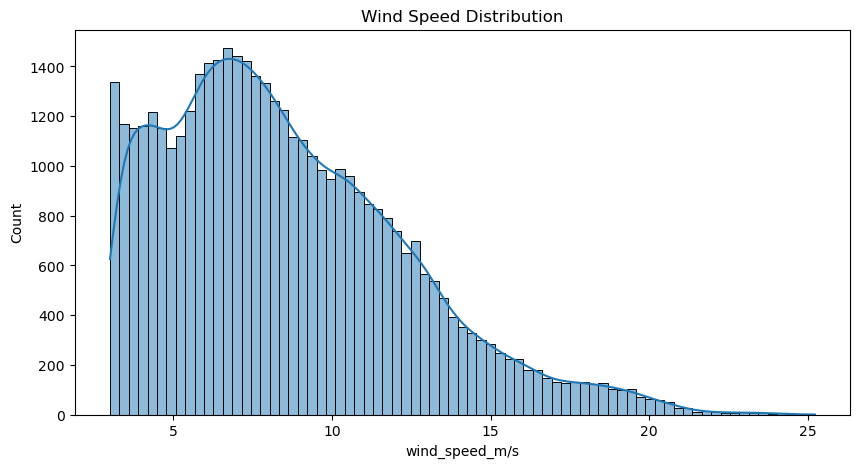

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['wind_speed_m/s'],
    kde=True
)

plt.title("Wind Speed Distribution")
plt.show()

Actual Power Histogram

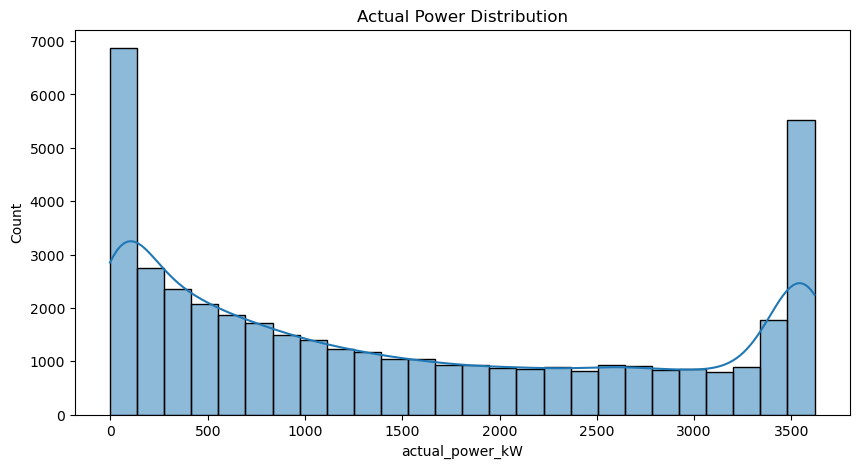

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['actual_power_kW'],
    kde=True
)

plt.title("Actual Power Distribution")
plt.show()

Normality Assessment

Q-Q Plot

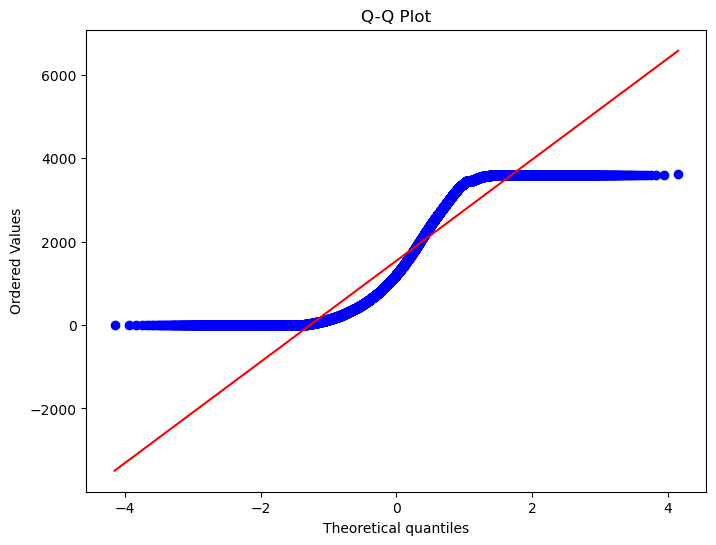

In [11]:
plt.figure(figsize=(8,6))

stats.probplot(
    df['actual_power_kW'],
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot")
plt.show()

Interpretation

If points follow the straight line,
the data is approximately normal.

Large deviations indicate non-normality.

Shapiro-Wilk Test

In [12]:
sample_data = df['actual_power_kW'].sample(
    n=5000,
    random_state=42
)

stat,p = shapiro(sample_data)

print("Statistic :", stat)
print("P-value :", p)

Statistic : 0.8794742226422696
P-value : 2.1037387912078985e-52


Interpretation

In [13]:
if p > 0.05:
    print("Data appears normal")
else:
    print("Data is not normally distributed")

Data is not normally distributed


Central Limit Theorem

In [14]:
def sampling_distribution(data,
                          sample_size,
                          n_samples=1000):

    means=[]

    for i in range(n_samples):

        sample=np.random.choice(
            data,
            size=sample_size,
            replace=True
        )

        means.append(sample.mean())

    return means

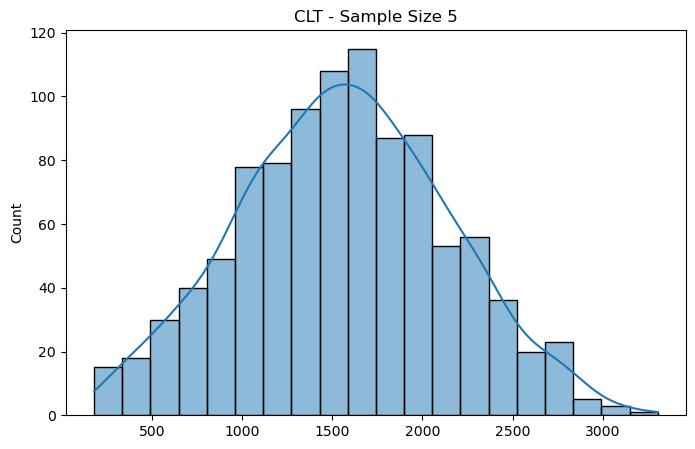

In [15]:
means_5 = sampling_distribution(
    df['actual_power_kW'],
    5
)

plt.figure(figsize=(8,5))

sns.histplot(
    means_5,
    kde=True
)

plt.title("CLT - Sample Size 5")
plt.show()

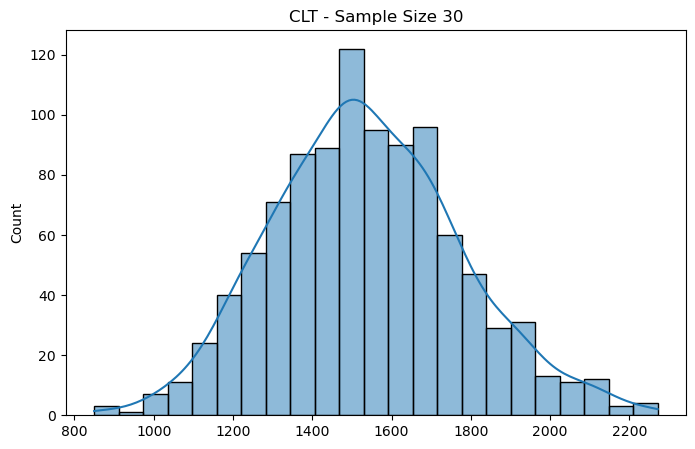

In [16]:
means_30 = sampling_distribution(
    df['actual_power_kW'],
    30
)

plt.figure(figsize=(8,5))

sns.histplot(
    means_30,
    kde=True
)

plt.title("CLT - Sample Size 30")
plt.show()

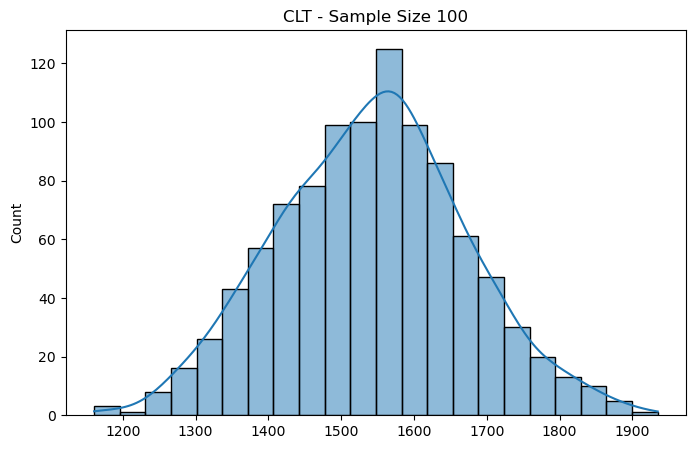

In [17]:
means_100 = sampling_distribution(
    df['actual_power_kW'],
    100
)

plt.figure(figsize=(8,5))

sns.histplot(
    means_100,
    kde=True
)

plt.title("CLT - Sample Size 100")
plt.show()

Interpretation

As sample size increases:

n = 5
Distribution is irregular

n = 30
Distribution becomes more symmetric

n = 100
Distribution approaches normality

This demonstrates the Central Limit Theorem.

Confidence Interval

In [18]:
sample = df['actual_power_kW'].sample(
    n=1000,
    random_state=42
)

mean = sample.mean()

std = sample.std()

n = len(sample)

In [19]:
z = 1.96

margin_error = z * (std / np.sqrt(n))

lower = mean - margin_error
upper = mean + margin_error

print("95% Confidence Interval")
print("Lower Bound :", lower)
print("Upper Bound :", upper)

95% Confidence Interval
Lower Bound : 1521.27389380484
Upper Bound : 1683.5220513338645


Interpretation

In [ ]:
print(
f"""
We are 95% confident that the true
population mean actual power lies
between {lower:.2f} and {upper:.2f}.
"""
)


We are 95% confident that the true
population mean actual power lies
between 1521.27 and 1683.52.



Final Summary

In [22]:
print("""
CONCLUSIONS

1. Random samples represent the population reasonably well.

2. Wind speed and power distributions were examined visually.

3. Normality was assessed using Q-Q plot and Shapiro-Wilk test.

4. Central Limit Theorem was validated using
sample sizes 5, 30 and 100.

5. A 95% confidence interval was constructed
for mean power generation.
""")


CONCLUSIONS

1. Random samples represent the population reasonably well.

2. Wind speed and power distributions were examined visually.

3. Normality was assessed using Q-Q plot and Shapiro-Wilk test.

4. Central Limit Theorem was validated using
sample sizes 5, 30 and 100.

5. A 95% confidence interval was constructed
for mean power generation.

